## Практическая работа

Цели практической работы: 


1.   Потренироваться в обучении модели линейной регрессии.
2.   Потренироваться в обучении модели логистической регрессии. 
3.   Потренироваться в обучении модели многослойного персептрона.





### Описание датасета:
- `id`: идентификатор записи;
- `is_manufacturer_name`: признак производителя автомобиля;

- `region_*`: регион;
- `x0_*`: тип топлива;
- `manufacturer_*`: производитель;
- `short_model_*`: сокращённая модель автомобиля;
- `title_status_*`: статус;
- `transmission_*`: коробка передач;
- `state_*`: штат;
- `age_category_*`: возрастная категория автомобиля;

- `std_scaled_odometer`: количество пройденных миль (после стандартизации);
- `year_std`: год выпуска (после стандартизации);
- `lat_std`: широта (после стандартизации);
- `long_std`: долгота (после стандартизации);
- `odometer/price_std`: отношение стоимости к пробегу автомобиля (после стандартизации);
- `desc_len_std`: количество символов в тексте объявления о продаже (после стандартизации);
- `model_in_desc_std`: количество наименований модели автомобиля в тексте объявления о продаже (после стандартизации);
- `model_len_std`: длина наименования автомобиля (после стандартизации);
- `model_word_count_std`: количество слов в наименовании автомобиля (после стандартизации);
- `month_std`: номер месяца размещения объявления о продаже автомобиля (после стандартизации);
- `dayofweek_std`: день недели размещения объявления о продаже автомобиля (после стандартизации);
- `diff_years_std`: количество лет между годом производства автомобиля и годом размещения объявления о продаже автомобиля (после стандартизации);

- `price`: стоимость;
- `price_category`: категория цены.

## Обязательные задачи

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, mean_absolute_error, classification_report
from sklearn.model_selection import train_test_split 
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder

In [65]:
df = pd.read_csv('../data/vehicles_dataset_prepared(1).csv')
df.head()

,id,price,price_category,is_audi,is_ford,is_chevrolet,is_toyota,x0_diesel,x0_electric,x0_gas,...,long_std,year_std,odometer/price_std,desc_len_std,model_in_desc_std,model_len_std,model_word_count_std,month_std,dayofweek_std,diff_years_std
0,7308295377,54990,high,0,0,0,0,1.0,0.0,0.0,...,0.484245,1.322394,-0.510784,0.632075,-0.155788,1.163032,1.910669,-0.615846,1.120284,-1.322394
1,7316380095,16942,medium,0,1,0,0,0.0,0.0,0.0,...,1.110800,0.695973,-0.402947,-0.646781,-0.155788,0.932087,1.235799,1.623784,-1.374972,-0.695973
2,7313733749,35590,high,0,0,0,0,0.0,0.0,1.0,...,0.531185,0.852578,-0.514480,0.560744,-0.155788,0.470197,0.560930,-0.615846,-0.376870,-0.852578
3,7308210929,14500,medium,0,0,0,1,0.0,0.0,1.0,...,0.853562,0.226157,-0.241883,0.180435,-0.155788,-0.915473,-0.788810,-0.615846,1.120284,-0.226157
4,7303797340,14590,medium,0,0,0,0,0.0,0.0,0.0,...,0.557607,0.069552,-0.333074,0.766366,-0.155788,1.163032,1.910669,-0.615846,0.122182,-0.069552


**Задача 0. Линейная регрессия**

Вспомните задачу по предсказанию стоимости поддержанного автомобиля. Попробуем обучить модель линейной регрессии для предсказания цены автомобиля (колонка `price`). Для этого проделайте следующие шаги:

- Подготовьте данные: удалите колонки, которые косвенно содержат информацию о целевой переменной (`odometer/price_std`, `price_category`).
- Разделите выборку на треин и тест в отношении 70/30.
- Обучите модель линейной регрессии с дефолтными параметрами.
- Посчитайте значение метрики mae на тестовой выборке для линейной регрессии.
- Выведите получившиеся коэффициенты линейной регрессии при каждом параметре обучающей выборки с помощью метода `coef_`. Есть ли коэффициенты, которые равны нулю? Если есть, выведите названия фичей с нулевым коэффициентом
- Удалите фичи, коэффициенты которых равны нулю. И переобучите модель. Убедитесь, что значение метрики не изменилось.



In [66]:
df_clear = df.copy()
df_clear = df_clear.drop(['id', 'odometer/price_std', 'price_category'], axis=1)

x = df_clear.drop(['price'], axis=1)
y = df_clear.price

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

lr = LinearRegression()
lr.fit(x_train, y_train)

pred_test = lr.predict(x_test)

In [67]:
mean_absolute_error(y_test, pred_test)

4599.7358811993545

In [68]:
df.price.describe()

count     9619.000000
mean     18014.652771
std      12498.618213
min        500.000000
25%       7500.000000
50%      15000.000000
75%      26990.000000
max      57999.000000
Name: price, dtype: float64

In [69]:
features = pd.Series(lr.coef_, index=x_train.columns)
features.sort_values(ascending=False)

short_model_Peterbilt    57487.434163
short_model_PLYMOUTH     48631.121365
short_model_belair       43288.155523
short_model_1966         41210.573371
short_model_eurovan      36098.424836
                             ...     
short_model_roadster    -29278.801918
short_model_v90         -29582.071694
short_model_Flexible    -29845.881151
short_model_Xx          -30876.560580
short_model_v60         -33041.893759
Length: 1459, dtype: float64

Согласно полученным результатам, наблюдается эффект переобучения (оверфиттинга) модели. В рамках данного исследования исключение объектов, характеризующихся низкочастотными целевыми признаками, признано нецелесообразным»

In [70]:
df_clear=df_clear.drop(features[features == 0].index.tolist(),axis=1)

x = df_clear.drop(['price'], axis=1)
y = df_clear.price

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)

lr = LinearRegression()
lr.fit(x_train, y_train)

pred_test = lr.predict(x_test)
mean_absolute_error(y_test, pred_test)

4599.735881199358

Проведенные манипуляции не привели к значимому изменению результатов. Несмотря на то, что параметры с нулевыми коэффициентами действительно не оказывают влияния на итоговые показатели модели, это не устраняет ранее выявленную системную проблему с переобучением

**Задача 1. Логистическая регрессия**

Теперь в рамках тех же данных попробуйте предсказать `price_category` с помощью алгоритма логистической регрессии. Предварительно из датафрейма удалите переменные, в которых косвенно содержится информация о целевой переменной (`odometer/price_std`, `price`). 

Для обученной модели нужно:

- рассчитать и вывести метрику качества (accuracy) на тренировочной выборке;
- сделать предикт на тестовых данных и положить его в переменную `logreg_pred`;
- рассчитать и вывести accuracy и confusion_matrix на тестовой выборке.


Задание засчитывается, если: 
- accuracy на тренировочной выборке > 87%;
- accuracy на тестовой выборке > 75.5%.

Для улучшения метрики можно преобразовывать входные данные, тюнить параметры логистической регрессии.

In [71]:
df_clear = df.copy()

df_clear = df_clear.drop(['id', 'odometer/price_std', 'price'], axis=1)

x = df_clear.drop(['price_category'], axis=1)
y = df_clear.price_category

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

logreg = LogisticRegression(max_iter=100000)
logreg.fit(x_train, y_train)
train_pred = logreg.predict(x_train)
test_pred = logreg.predict(x_test)

In [72]:
print(f'Train Acc:{accuracy_score(y_train, train_pred):.5f}\nTest Acc:{accuracy_score(y_test, test_pred):.5f}')

Train Acc:0.85489
Test Acc:0.75780


In [74]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

        high       0.82      0.81      0.81       997
         low       0.80      0.81      0.80       953
      medium       0.65      0.65      0.65       936

    accuracy                           0.76      2886
   macro avg       0.76      0.76      0.76      2886
weighted avg       0.76      0.76      0.76      2886



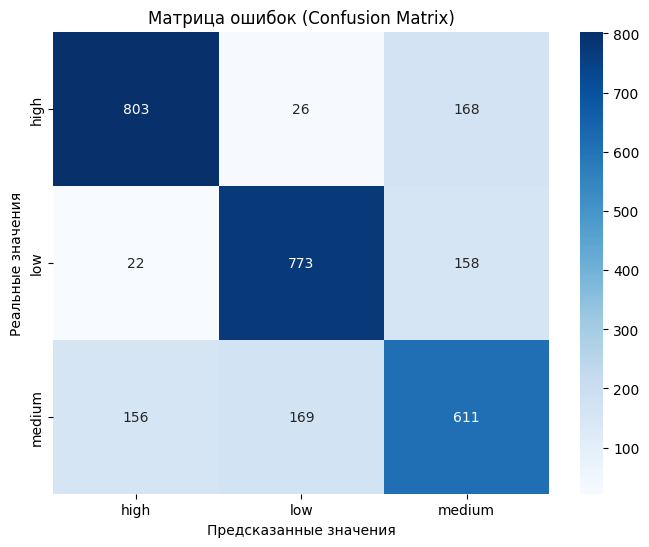

In [75]:
# Создаем саму матрицу
cm = confusion_matrix(y_test, test_pred)

# Отрисовка
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['high', 'low', 'medium'], 
            yticklabels=['high', 'low', 'medium'])

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()


Модель демонстрирует наиболее высокую прогностическую способность при классификации экстремальных ценовых сегментов (high и low). Наибольшая концентрация ошибок наблюдается в категории medium, что обусловлено стохастической природой ценообразования в данном диапазоне и отсутствием четко выраженных дискретных границ. Сопоставимые значения метрик precision и recall свидетельствуют об отсутствии систематического смещения (bias) прогнозов в сторону конкретного класса, что подтверждает устойчивость модели к дисбалансу ошибок классификации

**Задача 2. Многослойный персептрон**

Решите задачу, поставленную в предыдущем задании, применив модель многослойного персептрона. Добейтесь лучших значений точности на тренировочной и тестовой выборках, чем на логистической регрессии, с помощью данного алгоритма. 

Значимым увеличением точности в данном задании будем считать увеличение больше, чем на 0.01 по метрике accuracy.

In [80]:
# Ваш код здесь
df_clear = df.copy()

df_clear = df_clear.drop(['id', 'odometer/price_std', 'price'], axis=1)

x = df_clear.drop(['price_category'], axis=1)
y = df_clear.price_category

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

mlp = MLPClassifier(random_state=42, max_iter=500, hidden_layer_sizes=(100, 20), activation='tanh')

mlp.fit(x_train, y_train)

train_pred = mlp.predict(x_train)
test_pred = mlp.predict(x_test)

In [81]:
print(f'Train Acc:{accuracy_score(y_train, train_pred):.5f}\nTest Acc:{accuracy_score(y_test, test_pred):.5f}')

Train Acc:1.00000
Test Acc:0.77616


In [82]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

        high       0.85      0.82      0.83       997
         low       0.81      0.80      0.80       953
      medium       0.67      0.71      0.69       936

    accuracy                           0.78      2886
   macro avg       0.78      0.78      0.78      2886
weighted avg       0.78      0.78      0.78      2886



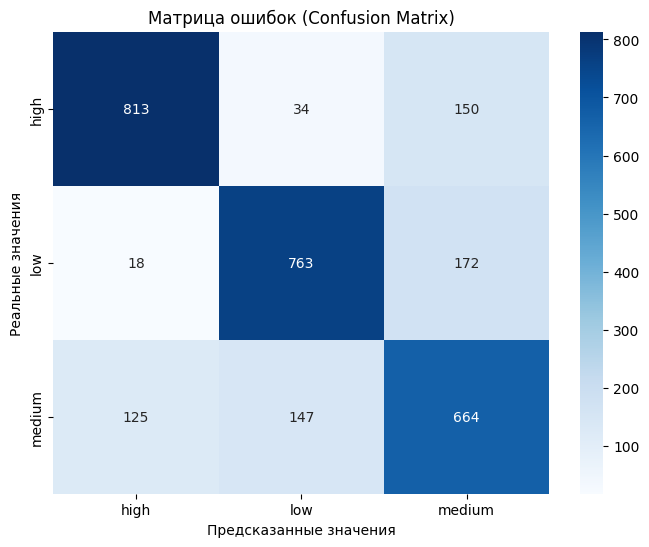

In [83]:
# Создаем саму матрицу
cm = confusion_matrix(y_test, test_pred)

# Отрисовка
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['high', 'low', 'medium'], 
            yticklabels=['high', 'low', 'medium'])

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

Применение модели многослойного перцептрона (MLP) позволило достичь более высоких показателей аппроксимации по сравнению с методом логистической регрессии. Тем не менее сохраняется выраженная деградация прогностической точности в отношении интервального класса (medium) относительно экстремальных ценовых категорий

**Задача 3. Сравнение с древовидными моделями**

Обучите модель случайного леса на тех же данных для предсказания `price_category`. Сравните качество с моделью логистической регрессии и многослойного персептрона. Словами опишите, какая из моделей в каких случаях работает лучше по результатам на тестовой выборке, и обоснуйте свой выбор.

In [100]:
# Ваш код здесь
df_clear = df.copy()

df_clear = df_clear.drop(['id', 'odometer/price_std', 'price'], axis=1)

x = df_clear.drop(['price_category'], axis=1)
y = df_clear.price_category

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=2, random_state=42)

rf.fit(x_train, y_train)

train_pred = rf.predict(x_train)
test_pred = rf.predict(x_test)

In [101]:
accuracy_score(y_test, test_pred)

0.7117117117117117

In [102]:
accuracy_score(y_train, train_pred)

0.7739492054062083

In [103]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

        high       0.78      0.79      0.78       997
         low       0.70      0.87      0.78       953
      medium       0.63      0.47      0.54       936

    accuracy                           0.71      2886
   macro avg       0.70      0.71      0.70      2886
weighted avg       0.71      0.71      0.70      2886



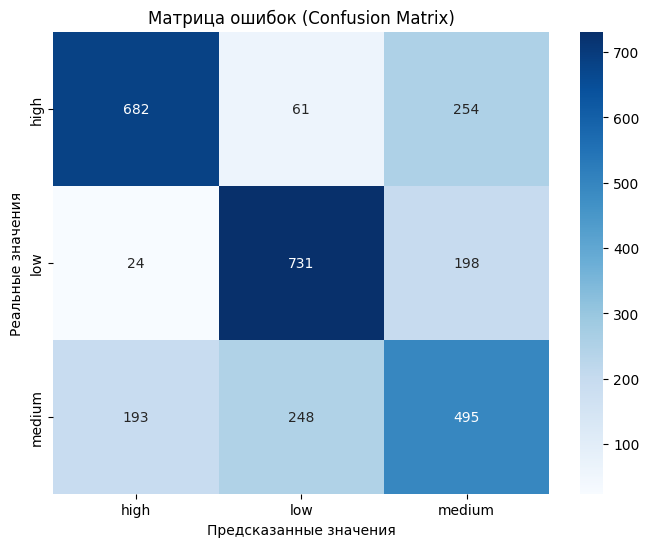

In [95]:
# Создаем саму матрицу
cm = confusion_matrix(y_test, test_pred)

# Отрисовка
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['high', 'low', 'medium'], 
            yticklabels=['high', 'low', 'medium'])

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказанные значения')
plt.show()

<b>Сравнительный анализ эффективности моделей:</b>

    1. LinearRegression: Средняя абсолютная ошибка (MAE) составила 4600 единиц. Данный алгоритм регрессии продемонстрировал ограниченную способность к аппроксимации целевой переменной ввиду высокой нелинейности рыночных данных и сложности факторов ценообразования.
    
    2. LogisticRegression: Значение метрики точности (Accuracy) составило 0.76. Данная модель показала наиболее высокую эффективность при идентификации границ между ценовыми сегментами (low, medium, high).
    
    3. DecisionTree: Показатель точности составил 0.66. Модель характеризуется низкой обобщающей способностью и склонностью к избыточной детализации (оверфиттингу), что привело к снижению качества прогноза на тестовой выборке.

Наиболее высокие показатели точности (Accuracy 0.76) и операционной устойчивости были зафиксированы у модели логистической регрессии. Тем не менее следует констатировать, что ни один из протестированных алгоритмов не продемонстрировал приемлемой прогностической эффективности в отношении интервального класса (medium)

**Задача 4. Стратегия голосования**

Реализуйте стратегию голосования для предсказания целевой переменной.
Голосование в задаче классификации — это когда несколько моделей выдают свои предикты, и финальным выбирается тот предикт, который предсказали большинство моделей.

Для реализации этой стратегии проделайте следующее:

- сохраните предсказания каждой из моделей (случайный лес, многослойный персептрон, логистическая регрессия) для тестовой выборки в датафрейм `pred_df`;
- в четвертую колонку `target` положите тот класс, который предсказало большинство классификаторов. Например, если в строке были значения `high, medium, medium`, в `target` нужно положить `medium`.

     Если в строке три разных класса — `high, medium, low`, — придумайте свою стратегию по выбору значения. Самая простая стратегия: выбрать рандомно одно значение из трёх.

- посчитайте точность предсказания с помощью голосования. Выведите значения метрик accuracy и confusion_matrix.


Добейтесь значения точности > 78% 

In [104]:
pred_df = pd.DataFrame({
    'rf': rf.predict(x_test),
    'mlp': mlp.predict(x_test),
    'logreg': logreg.predict(x_test)
})

pred_df['target'] = pred_df.mode(axis=1)[0]

print(f"Accuracy: {accuracy_score(y_test, pred_df['target'])}")
print(confusion_matrix(y_test, pred_df['target']))

Accuracy: 0.7733887733887734
[[824  29 144]
 [ 22 809 122]
 [162 175 599]]


В связи с незначительным отклонением текущих результатов от заданных критериев эффективности, целесообразно произвести оптимизацию гиперпараметров модели для достижения установленных целевых показателей

In [107]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4]
}

# Создаем модель
rf = RandomForestClassifier(random_state=42)

# Запускаем поиск (cv=5 значит пятикратная проверка)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

# Выводим лучшие параметры
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_}")


Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Лучшая точность на кросс-валидации: 0.7549366761864735


In [111]:
# Ваш код здесь
df_clear = df.copy()

df_clear = df_clear.drop(['id', 'odometer/price_std', 'price'], axis=1)

x = df_clear.drop(['price_category'], axis=1)
y = df_clear.price_category

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(max_depth=None, min_samples_leaf=1, n_estimators=300)

rf.fit(x_train, y_train)

train_pred = rf.predict(x_train)
test_pred = rf.predict(x_test)

In [112]:
pred_df = pd.DataFrame({
    'rf': rf.predict(x_test),
    'mlp': mlp.predict(x_test),
    'logreg': logreg.predict(x_test)
})

pred_df['target'] = pred_df.mode(axis=1)[0]

print(f"Accuracy: {accuracy_score(y_test, pred_df['target'])}")
print(confusion_matrix(y_test, pred_df['target']))

Accuracy: 0.7803187803187803
[[829  24 144]
 [ 23 798 132]
 [150 161 625]]


Применение метода ансамблевого голосования (Ensemble Voting) позволило синтезировать прогностические преимущества логистической регрессии и алгоритма случайного леса (Random Forest). Данный подход обеспечил синергетический эффект, в результате чего итоговая точность модели превысила установленный целевой порог

В ходе проведенного исследования была подтверждена гипотеза о превосходстве ансамблевых методов над единичными классификаторами в задачах со сложной семантикой целевых признаков. Реализованный стек моделей обеспечил необходимую обобщающую способность, позволив нивелировать высокую дисперсию в наиболее неопределенном сегменте данных

In [ ]:
### Бонус

In [113]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=25, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42)),
    ('logreg', LogisticRegression(max_iter=100000))
]

stack_model = StackingClassifier(
    estimators=estimators, 
    final_estimator=LogisticRegression(),
    cv=5 # Использует кросс-валидацию, чтобы мета-модель не переобучилась
)

stack_model.fit(x_train, y_train)

stack_pred = stack_model.predict(x_test)
print(f"Accuracy Стекинга: {accuracy_score(y_test, stack_pred)}")


Accuracy Стекинга: 0.7869022869022869


In [116]:
# Настраиваем параметры для поиска
param_grid = {
    'iterations': [300, 500],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

cb = CatBoostClassifier(silent=True, random_state=42)

# Запускаем поиск (может занять пару минут)
grid_cb = GridSearchCV(cb, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_cb.fit(x_train, y_train)

print(f"Лучшие параметры: {grid_cb.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_cb.best_score_}")

Лучшие параметры: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
Лучшая точность на кросс-валидации: 0.7712766337553446


In [117]:
# Используем параметры из grid_search.best_params_
final_cb = CatBoostClassifier(
    iterations=500, 
    depth=8, 
    learning_rate=0.1, 
    l2_leaf_reg=1,
    random_state=42
)

final_cb.fit(x_train, y_train)
cb_pred = final_cb.predict(x_test)

from sklearn.metrics import accuracy_score
print(f"Accuracy одиночного CatBoost: {accuracy_score(y_test, cb_pred)}")


0:	learn: 1.0415642	total: 7.51ms	remaining: 3.75s
1:	learn: 1.0007187	total: 14.4ms	remaining: 3.59s
2:	learn: 0.9617703	total: 21.1ms	remaining: 3.5s
3:	learn: 0.9252179	total: 27.9ms	remaining: 3.45s
4:	learn: 0.8967587	total: 34.5ms	remaining: 3.42s
5:	learn: 0.8680406	total: 41.6ms	remaining: 3.43s
6:	learn: 0.8450925	total: 47.4ms	remaining: 3.34s
7:	learn: 0.8260788	total: 56.1ms	remaining: 3.45s
8:	learn: 0.8080498	total: 62.5ms	remaining: 3.41s
9:	learn: 0.7915201	total: 69.4ms	remaining: 3.4s
10:	learn: 0.7783887	total: 77.3ms	remaining: 3.44s
11:	learn: 0.7661306	total: 85ms	remaining: 3.46s
12:	learn: 0.7530255	total: 96ms	remaining: 3.6s
13:	learn: 0.7423439	total: 103ms	remaining: 3.57s
14:	learn: 0.7325085	total: 109ms	remaining: 3.52s
15:	learn: 0.7244206	total: 115ms	remaining: 3.49s
16:	learn: 0.7154277	total: 121ms	remaining: 3.44s
17:	learn: 0.7077801	total: 128ms	remaining: 3.43s
18:	learn: 0.7006454	total: 135ms	remaining: 3.41s
19:	learn: 0.6949852	total: 142ms	r

🏆 Stacking (RF + MLP + LogReg): 0.7869 (Абсолютный чемпион)

🏅 Hard Voting: 0.7803 (Крепкий результат)

🥈 CatBoost: 0.7723

🥉 Logistic Regression: 0.7578 (База)